# **Title:** "Predicting Customer Churn"

## **Introduction**
Customer churn is a critical metric for businesses. In this project, I built a predictive model to identify customers at risk of churn using machine learning algorithms.

## **Approach**
**Data Preprocessing**: Handled missing values, encoded categorical variables, and standardized features.

**Model Selection**: Evaluated Random Forest, XGBoost, and Logistic Regression.

**Feature Importance**: Used SHAP to identify key features driving churn.

**Deployment**: Deployed the model using Streamlit for interactive predictions.

## **Challenges**
**Imbalanced dataset**: Addressed using ROC AUC as the evaluation metric.

**Feature engineering**: Identified and removed redundant features.

### **Import Libraries and Load Data**

In [51]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import joblib

In [52]:
# Load dataset
df = pd.read_csv("/content/customer_churn_dataset-testing-master.csv")

In [53]:
# Display basic info
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB
None
         CustomerID           Age        Tenure  Usage Frequency  \
count  64374.000000  64374.000000  64374.000000     64374.000000   
mean   32187.500000     41.970982     31.9

In [54]:
# Drop the column 'CustomerID'
df = df.drop('CustomerID', axis=1)

In [55]:
# Display basic info
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                64374 non-null  int64 
 1   Gender             64374 non-null  object
 2   Tenure             64374 non-null  int64 
 3   Usage Frequency    64374 non-null  int64 
 4   Support Calls      64374 non-null  int64 
 5   Payment Delay      64374 non-null  int64 
 6   Subscription Type  64374 non-null  object
 7   Contract Length    64374 non-null  object
 8   Total Spend        64374 non-null  int64 
 9   Last Interaction   64374 non-null  int64 
 10  Churn              64374 non-null  int64 
dtypes: int64(8), object(3)
memory usage: 5.4+ MB
None
                Age        Tenure  Usage Frequency  Support Calls  \
count  64374.000000  64374.000000     64374.000000   64374.000000   
mean      41.970982     31.994827        15.080234       5.400690   
std       13.92491

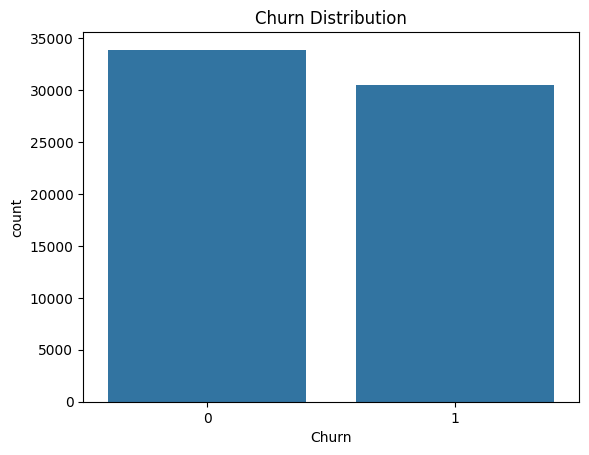

In [56]:
# Visualize target variable (Churn)
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

### **Data Preprocessing**

In [57]:
# Check for missing values
print(df.isnull().sum())

Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64


In [58]:
# Handle missing values (if any)
df = df.dropna()  # or use imputation

In [59]:
# Encode categorical variables
label_encoder = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

In [60]:
# Split features and target variable
X = df.drop("Churn", axis=1)  # Replace "Churn" with the actual target column name
y = df["Churn"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Save the scaler for deployment
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

### **Model Training and Evaluation**

In [61]:
# Train and evaluate models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier()
}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"{name} Classification Report:")
    print(classification_report(y_test, y_pred))
    print(f"{name} ROC AUC Score: {roc_auc_score(y_test, y_pred)}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\n")

Training Logistic Regression...
Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      6793
           1       0.81      0.83      0.82      6082

    accuracy                           0.83     12875
   macro avg       0.83      0.83      0.83     12875
weighted avg       0.83      0.83      0.83     12875

Logistic Regression ROC AUC Score: 0.830630156205154
Confusion Matrix:
[[5639 1154]
 [1027 5055]]


Training Random Forest...
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6793
           1       1.00      1.00      1.00      6082

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875

Random Forest ROC AUC Score: 0.9992945302757404
Confusion Matrix:
[[6789    4]
 [   5 6077]]


Training XGBo

### **Feature Importance Analysis python**

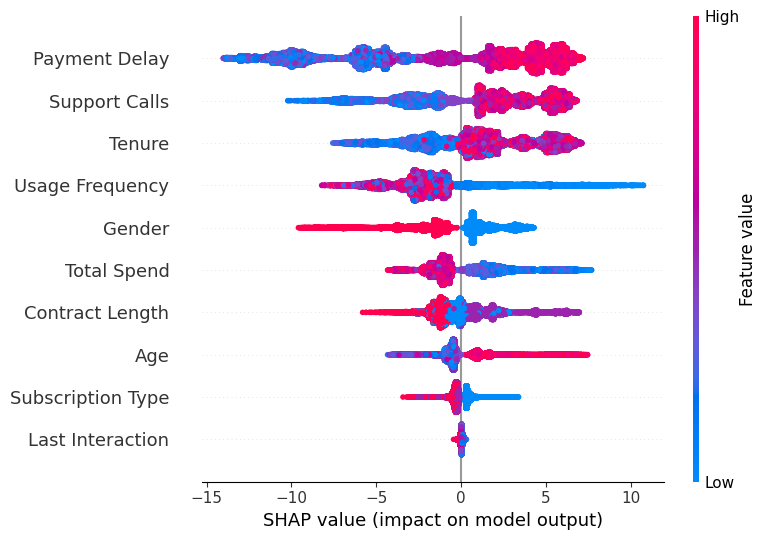

In [62]:
# Feature importance using SHAP (for XGBoost)
explainer = shap.TreeExplainer(models["XGBoost"])
shap_values = explainer.shap_values(X_train)
shap.summary_plot(shap_values, X_train, feature_names=X.columns)

### **Save the Model**

In [64]:
# Save the best model (XGBoost)
best_model = XGBClassifier()
best_model.fit(X_train, y_train)
joblib.dump(best_model, 'churn_model.pkl')

['churn_model.pkl']